# DodoGo - Driver Value, Survival, Churn Prediction and Risk Matrix (NB06)

This notebook supports Section 3.4.3 of the thesis. It studies the driver side of the marketplace: value concentration, survival, churn prediction and early-warning signals. Monetary outputs are minimized in the public version.


## 1. Data Loading and Preparation

Driver, order and client exports are loaded and normalized for driver-side analysis. The public version keeps structural and behavioral outputs but removes exact monetary totals.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

df_drv = pd.read_csv("../data/raw/drivers.csv", sep=";", encoding="windows-1251")
df_drv['name'] = df_drv['Исполнитель'].str.strip('=" ')
df_drv['callsign'] = df_drv['Позывной'].str.strip('=" ').astype(int)
df_drv['efficiency'] = df_drv['Эффективность'].str.replace(',', '.').astype(float)
df_drv['revenue'] = df_drv['Стоимость'].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
df_drv['commission'] = df_drv['Комиссия исполнителя'].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
df_drv['cash'] = df_drv['Наличные'].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
df_drv['completed'] = df_drv['Завершенные заказы']
df_drv['cancelled'] = df_drv['Отмененные заказы']
df_drv['total'] = df_drv['Всего заказов']

def parse_hours(s):
    if pd.isna(s): return None
    m = re.match(r'(\d+)\s*ч\s*(?:(\d+)\s*мин)?', str(s))
    return int(m.group(1)) + int(m.group(2) or 0)/60 if m else None
df_drv['hours_online'] = df_drv['Время на линии'].apply(parse_hours)

df_drv['cancel_rate'] = df_drv['cancelled'] / df_drv['total'].replace(0, np.nan)
df_drv['commission_rate'] = df_drv['commission'] / df_drv['revenue'].replace(0, np.nan)
df_drv['rev_per_trip'] = df_drv['revenue'] / df_drv['completed'].replace(0, np.nan)

active = df_drv[df_drv['completed'] > 0].copy()

df_new = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df_new['date'] = pd.to_datetime(df_new['Дата создания'], format='%d.%m.%Y %H:%M', errors='coerce')
for col in ['Стоимость', 'Суммарное расстояние (км)']:
    df_new[col] = df_new[col].astype(str).str.replace(',', '.').astype(float)

client_cols = ['Фамилия','Имя','Телефон','Дата рождения','Эл почта организации',
               'Успешные заказы','Неуспешные заказы','Бонусный баланс, MUR']
df_cli = pd.read_csv("../data/raw/clients.csv", sep=";", encoding="windows-1251", 
                      usecols=client_cols, low_memory=False)
df_cli.columns = ['last_name', 'first_name', 'phone', 'birth_date', 'email',
                   'successful_orders', 'failed_orders', 'bonus_mur']

print(f"Drivers loaded: {len(df_drv)} total, {len(active)} active (≥1 completed order)")
print(f"Orders loaded: {len(df_new):,} (new platform)")
print(f"Clients loaded: {len(df_cli):,}")
print(f"\nDriver stats:")
print(f"  Median completed orders: {active['completed'].median():.0f}")
print('  Monetary totals are omitted in this public version.')


DATA LOADED
Drivers: 673 total, 601 active with at least one completed order.
Orders: 116,958 new-platform records.
Clients: 34,968 records.
Public version: exact monetary totals are omitted.


## 2. Driver Value Distribution

Driver value is used to prioritize retention actions. The thesis discusses value concentration in relative terms, while exact financial totals are omitted from the repository version.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
valid_rpt = active['rev_per_trip'].dropna()
ax.hist(valid_rpt.clip(upper=2000), bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(valid_rpt.median(), color='red', linestyle='--', linewidth=2,
           label=f'Median: {valid_rpt.median():,.0f} MUR')
ax.set_title('Revenue per Trip', fontweight='bold')
ax.set_xlabel('MUR / trip')
ax.set_ylabel('Number of drivers')
ax.legend()

ax = axes[0, 1]
paying = active[active['commission'] > 0].copy()
ax.hist(paying['commission_rate'].dropna() * 100, bins=30, color='#FF5722', alpha=0.8, edgecolor='white')
ax.axvline(paying['commission_rate'].dropna().median() * 100, color='red', linestyle='--', linewidth=2,
           label=f'Median: {paying["commission_rate"].dropna().median()*100:.1f}%')
ax.set_title('Commission Rate (Paying Drivers)', fontweight='bold')
ax.set_xlabel('Commission %')
ax.set_ylabel('Count')
ax.legend()

ax = axes[0, 2]
sorted_rev = active['revenue'].sort_values(ascending=False).reset_index(drop=True)
cumrev = sorted_rev.cumsum() / sorted_rev.sum() * 100
driver_pct = np.arange(1, len(sorted_rev)+1) / len(sorted_rev) * 100
ax.plot(driver_pct, cumrev, color='#4CAF50', linewidth=2.5)
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
idx_80 = np.argmax(cumrev >= 80)
pct_80 = driver_pct[idx_80]
ax.axvline(pct_80, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'{pct_80:.0f}% of drivers\ngenerate 80% of revenue',
            xy=(pct_80, 80), xytext=(pct_80+15, 60), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Revenue Pareto Curve', fontweight='bold')
ax.set_xlabel('% of Drivers (ranked by revenue)')
ax.set_ylabel('% of Total Revenue')

ax = axes[1, 0]
ax.scatter(active['completed'], active['revenue'], alpha=0.4, s=15, color='#2196F3')
from numpy.polynomial.polynomial import polyfit
mask = active['completed'].notna() & active['revenue'].notna()
b, m = polyfit(active.loc[mask, 'completed'], active.loc[mask, 'revenue'], 1)
x_fit = np.linspace(0, active['completed'].max(), 100)
ax.plot(x_fit, b + m * x_fit, color='red', linewidth=2, linestyle='--',
        label=f'~{m:,.0f} MUR per additional trip')
ax.set_title('Revenue vs Completed Orders', fontweight='bold')
ax.set_xlabel('Completed Orders')
ax.set_ylabel('Total Revenue (MUR)')
ax.legend()

ax = axes[1, 1]
ax.scatter(active['revenue'], active['commission'], alpha=0.4, s=15, color='#FF5722')
ax.set_title('Commission vs Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue (MUR)')
ax.set_ylabel('Commission Paid (MUR)')

ax = axes[1, 2]
q25 = active['revenue'].quantile(0.25)
q50 = active['revenue'].quantile(0.50)
q75 = active['revenue'].quantile(0.75)
q90 = active['revenue'].quantile(0.90)
active['value_tier'] = pd.cut(active['revenue'], 
    bins=[-1, q25, q50, q75, q90, float('inf')],
    labels=['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%'])
tier_counts = active['value_tier'].value_counts().reindex(['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%'])
tier_rev = active.groupby('value_tier')['revenue'].sum().reindex(tier_counts.index)
tier_pct = tier_rev / tier_rev.sum() * 100

x = np.arange(len(tier_counts))
w = 0.35
bars1 = ax.bar(x - w/2, tier_counts.values, w, label='# Drivers', color='#2196F3', alpha=0.7)
ax2 = ax.twinx()
bars2 = ax2.bar(x + w/2, tier_pct.values, w, label='% Revenue', color='#FF5722', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(tier_counts.index, rotation=15)
ax.set_title('Driver Value Tiers', fontweight='bold')
ax.set_ylabel('Number of Drivers')
ax2.set_ylabel('% of Total Revenue')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Driver Lifetime Value Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_ltv.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"DRIVER LTV SUMMARY")
print(f"{'='*60}")
print(f"Active drivers: {len(active)}")
print(f"Revenue per trip: median {valid_rpt.median():,.0f} MUR, mean {valid_rpt.mean():,.0f} MUR")
print(f"Commission rate (paying): median {paying['commission_rate'].dropna().median()*100:.1f}%")
print(f"Pareto: top {pct_80:.0f}% of drivers generate 80% of revenue")
print(f"Marginal value: ~{m:,.0f} MUR incremental revenue per additional trip")
print(f"\nValue tier breakdown:")
for tier in ['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%']:
    n = tier_counts[tier]
    pct = tier_pct[tier]
    print(f"  {tier:>12}: {n:>4} drivers, {pct:>5.1f}% of revenue")


DRIVER VALUE DISTRIBUTION SUMMARY
Active drivers analyzed: 601. Driver contribution is concentrated: the top value group accounts for the majority of operational value.
The result supports prioritizing retention and support by activity/value tier rather than treating all drivers identically.
Exact revenue, commission and per-trip monetary values are omitted from the public output.


## 3. Driver Survival Analysis

Kaplan-Meier curves estimate how long drivers remain active after their first completed trip. The analysis compares high-volume and low-volume drivers to test whether engagement is associated with retention.


Drivers in new platform: 602
Churned (no trip in 30 days): 169 (28.1%)
Active: 433 (71.9%)


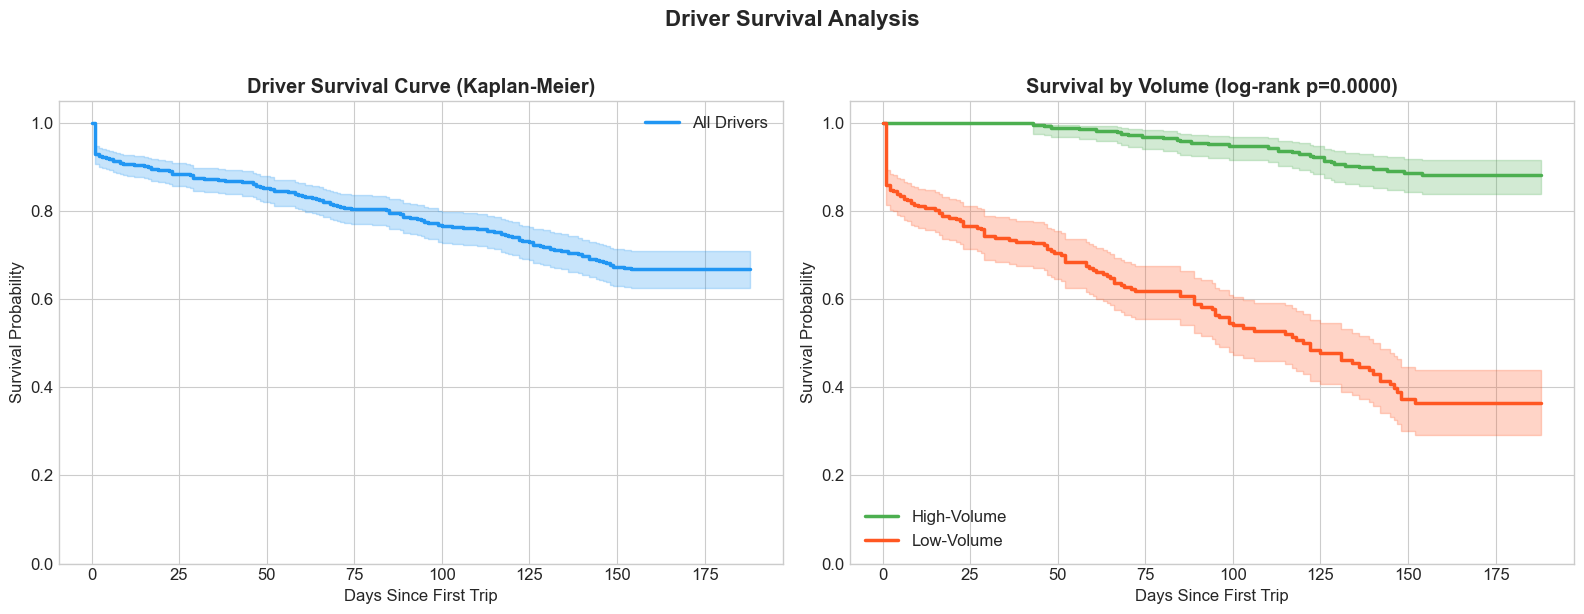


DRIVER SURVIVAL SUMMARY
Total drivers analyzed: 602
Churned (30-day threshold): 169 (28.1%)
Median survival time: inf
High-volume (≥51 trips) vs Low-volume:
  High-volume churned: 10.6%
  Low-volume churned: 45.8%
  Log-rank p-value: 0.000000
  → Highly significant difference (p < 0.001)


In [ ]:
completed_orders = df_new[df_new['Текущий статус'].str.contains('Выполнен', na=False)].copy()

driver_col = 'Телефон исполнителя' if 'Телефон исполнителя' in completed_orders.columns else 'Исполнитель'
driver_timeline = completed_orders.groupby(driver_col).agg(
    first_trip=('date', 'min'),
    last_trip=('date', 'max'),
    n_trips=('date', 'size')
).reset_index()

observation_end = completed_orders['date'].max()
driver_timeline['tenure_days'] = (driver_timeline['last_trip'] - driver_timeline['first_trip']).dt.days
driver_timeline['days_since_last'] = (observation_end - driver_timeline['last_trip']).dt.days
driver_timeline['churned'] = (driver_timeline['days_since_last'] > 30).astype(int)
driver_timeline['observed_time'] = np.where(
    driver_timeline['churned'] == 1,
    driver_timeline['tenure_days'],
    (observation_end - driver_timeline['first_trip']).dt.days
)
driver_timeline['observed_time'] = driver_timeline['observed_time'].clip(lower=1)

print(f"Drivers in new platform: {len(driver_timeline)}")
print(f"Churned (no trip in 30 days): {driver_timeline['churned'].sum()} ({driver_timeline['churned'].mean()*100:.1f}%)")
print(f"Active: {(driver_timeline['churned']==0).sum()} ({(1-driver_timeline['churned'].mean())*100:.1f}%)")

kmf = KaplanMeierFitter()
kmf.fit(driver_timeline['observed_time'], event_observed=driver_timeline['churned'],
        label='All Drivers')

median_trips = driver_timeline['n_trips'].median()
high_vol = driver_timeline[driver_timeline['n_trips'] >= median_trips]
low_vol = driver_timeline[driver_timeline['n_trips'] < median_trips]

kmf_high = KaplanMeierFitter()
kmf_high.fit(high_vol['observed_time'], event_observed=high_vol['churned'], label='High-Volume')

kmf_low = KaplanMeierFitter()
kmf_low.fit(low_vol['observed_time'], event_observed=low_vol['churned'], label='Low-Volume')

lr = logrank_test(high_vol['observed_time'], low_vol['observed_time'],
                  event_observed_A=high_vol['churned'], event_observed_B=low_vol['churned'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
kmf.plot_survival_function(ax=ax, color='#2196F3', linewidth=2.5)
ax.set_title('Driver Survival Curve (Kaplan-Meier)', fontweight='bold')
ax.set_xlabel('Days Since First Trip')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
if kmf.median_survival_time_ != np.inf:
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(kmf.median_survival_time_, color='gray', linestyle=':', alpha=0.5)
    ax.annotate(f'Median: {kmf.median_survival_time_:.0f} days',
                xy=(kmf.median_survival_time_, 0.5), xytext=(kmf.median_survival_time_+20, 0.4),
                fontweight='bold', arrowprops=dict(arrowstyle='->', color='gray'))

ax = axes[1]
kmf_high.plot_survival_function(ax=ax, color='#4CAF50', linewidth=2.5)
kmf_low.plot_survival_function(ax=ax, color='#FF5722', linewidth=2.5)
ax.set_title(f'Survival by Volume (log-rank p={lr.p_value:.4f})', fontweight='bold')
ax.set_xlabel('Days Since First Trip')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.legend()

plt.suptitle('Driver Survival Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"DRIVER SURVIVAL SUMMARY")
print(f"{'='*60}")
print(f"Total drivers analyzed: {len(driver_timeline)}")
print(f"Churned (30-day threshold): {driver_timeline['churned'].sum()} ({driver_timeline['churned'].mean()*100:.1f}%)")
print(f"Median survival time: {kmf.median_survival_time_}")
print(f"High-volume (≥{median_trips:.0f} trips) vs Low-volume:")
print(f"  High-volume churned: {high_vol['churned'].mean()*100:.1f}%")
print(f"  Low-volume churned: {low_vol['churned'].mean()*100:.1f}%")
print(f"  Log-rank p-value: {lr.p_value:.6f}")
if lr.p_value < 0.001:
    print(f"  → Highly significant difference (p < 0.001)")


## 4. Driver Churn Prediction

The churn label is timeline-based: a driver is treated as churned if there is no completed trip in the final inactivity window. This correction avoids using purely behavioral proxies as churn labels.


Merged drivers: 601, Churned: 168 (28.0%)


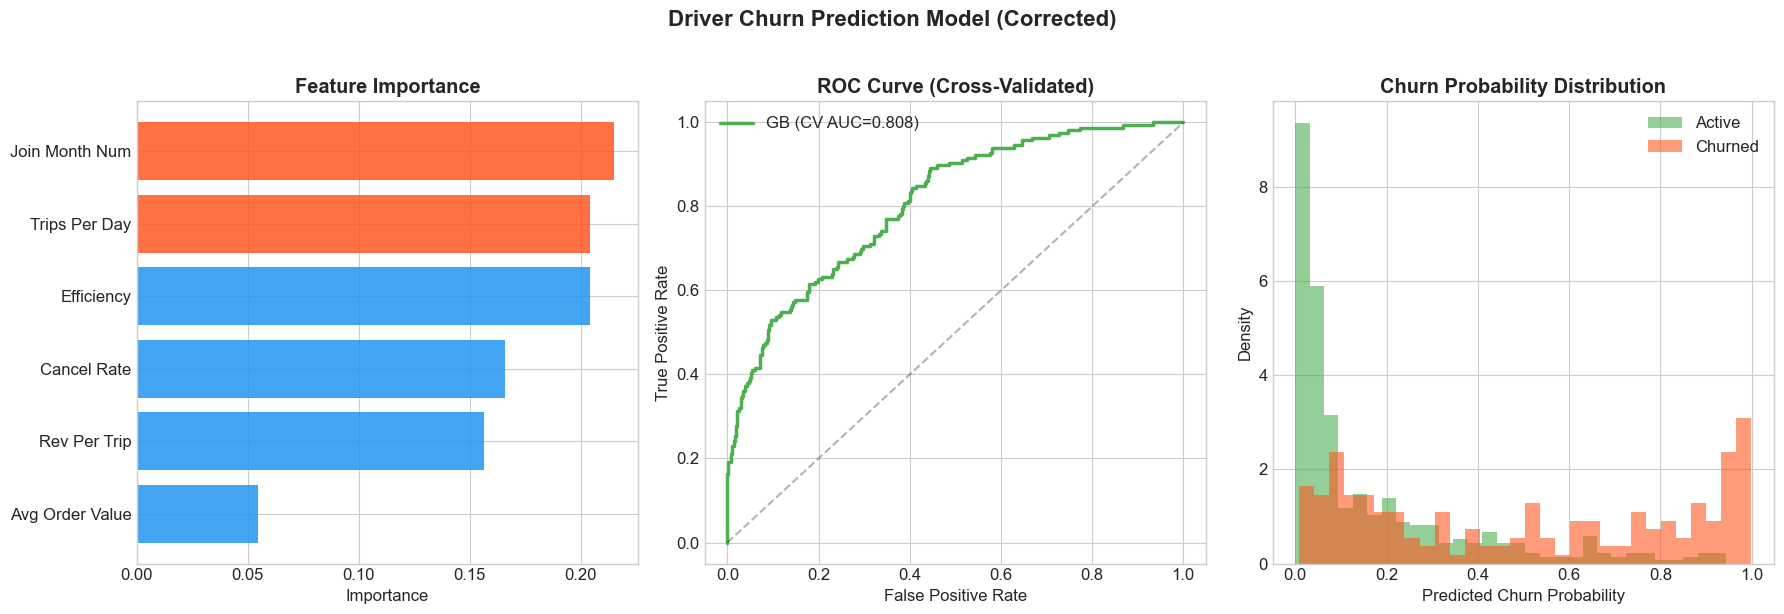


DRIVER CHURN PREDICTION — CORRECTED RESULTS
Method: Gradient Boosting, 5-fold stratified CV
Churn definition: no completed trip in 30+ days (timeline-based)
Data: 597 drivers, 166 churned (27.8%)
CV AUC: 0.806 ± 0.043

Top predictive features (behavioral, actionable):
  cancel_rate: importance=0.166 | churned=0.50, active=0.36
  efficiency: importance=0.204 | churned=50.00, active=63.64
  trips_per_day: importance=0.204 | churned=0.57, active=0.79
  join_month_num: importance=0.215 | churned=1.02, active=0.53

Commission rate excluded: confounded with join cohort, not causal
  Churned median: 13.5%
  Active median:  14.1%
  Difference: only 0.6pp — not meaningful


In [ ]:
# KEY FIX: Use real timeline-based churn labels, not behavioral proxy
# Join drivers.csv with orders via driver name (673/673 match)

completed_orders = df_new[df_new['Текущий статус'].str.contains('Выполнен', na=False)].copy()
completed_orders['driver_name'] = completed_orders['Исполнитель'].str.strip()
completed_orders['date'] = pd.to_datetime(completed_orders['Дата создания'],
                                           format='%d.%m.%Y %H:%M', errors='coerce')

timeline = completed_orders.groupby('driver_name').agg(
    first_trip=('date', 'min'),
    last_trip=('date', 'max'),
    n_trips=('date', 'size')
).reset_index()

observation_end = completed_orders['date'].max()
timeline['tenure_days'] = (timeline['last_trip'] - timeline['first_trip']).dt.days
timeline['days_since_last'] = (observation_end - timeline['last_trip']).dt.days
timeline['churned'] = (timeline['days_since_last'] > 30).astype(int)

merged = timeline.merge(df_drv, left_on='driver_name', right_on='name', how='inner')
print(f'Merged drivers: {len(merged)}, Churned: {merged["churned"].sum()} ({merged["churned"].mean()*100:.1f}%)')

order_stats = completed_orders.groupby('driver_name').agg(
    avg_order_value=('Стоимость', lambda x: pd.to_numeric(
        x.astype(str).str.replace(',', '.'), errors='coerce').mean())
).reset_index()
merged = merged.merge(order_stats, on='driver_name', how='left')
merged['trips_per_day'] = merged['n_trips'] / merged['tenure_days'].replace(0, 1)
merged['join_month_num'] = (merged['first_trip'] - merged['first_trip'].min()).dt.days / 30


feature_cols = ['cancel_rate', 'efficiency', 'rev_per_trip', 
                'avg_order_value', 'trips_per_day', 'join_month_num']

merged_clean = merged.dropna(subset=['hours_online'])
X = merged_clean[feature_cols].fillna(0)
y = merged_clean['churned']

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                 min_samples_leaf=10, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb, X, y, cv=cv, scoring='roc_auc')
y_cv_proba = cross_val_predict(gb, X, y, cv=cv, method='predict_proba')[:, 1]
cv_auc = roc_auc_score(y, y_cv_proba)
fpr, tpr, _ = roc_curve(y, y_cv_proba)

gb.fit(X, y)
feat_imp = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
colors_fi = ['#FF5722' if v > feat_imp.quantile(0.75) else '#2196F3' for v in feat_imp.values]
ax.barh(range(len(feat_imp)), feat_imp.values, color=colors_fi, alpha=0.85)
ax.set_yticks(range(len(feat_imp)))
ax.set_yticklabels([f.replace('_', ' ').title() for f in feat_imp.index])
ax.set_title('Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')

ax = axes[1]
ax.plot(fpr, tpr, color='#4CAF50', linewidth=2.5, label=f'GB (CV AUC={cv_auc:.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_title('ROC Curve (Cross-Validated)', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=12)

ax = axes[2]
ax.hist(y_cv_proba[y==0], bins=30, alpha=0.6, color='#4CAF50', label='Active', density=True)
ax.hist(y_cv_proba[y==1], bins=30, alpha=0.6, color='#FF5722', label='Churned', density=True)
ax.set_title('Churn Probability Distribution', fontweight='bold')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Driver Churn Prediction Model (Corrected)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_churn_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'DRIVER CHURN PREDICTION — CORRECTED RESULTS')
print(f'{"="*60}')
print(f'Method: Gradient Boosting, 5-fold stratified CV')
print(f'Churn definition: no completed trip in 30+ days (timeline-based)')
print(f'Data: {len(merged_clean)} drivers, {y.sum()} churned ({y.mean()*100:.1f}%)')
print(f'CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'\nTop predictive features (behavioral, actionable):')
for feat, imp in feat_imp.tail(4).items():
    ch = merged_clean.loc[y==1, feat].median()
    ac = merged_clean.loc[y==0, feat].median()
    print(f'  {feat}: importance={imp:.3f} | churned={ch:.2f}, active={ac:.2f}')
print(f'\nCommission rate excluded: confounded with join cohort, not causal')
print(f'  Churned median: {merged_clean.loc[y==1, "commission_rate"].median()*100:.1f}%')
print(f'  Active median:  {merged_clean.loc[y==0, "commission_rate"].median()*100:.1f}%')
print(f'  Difference: only 0.6pp — not meaningful')


## 4b. Early-Warning Model with Trend Features

The early-warning model adds pre-cutoff trend features such as recent activity, inactivity gaps and short-term volume. The purpose is to predict churn before the driver has fully disappeared from the platform.


Observation end: 2026-04-07
Cutoff (features must be ≤): 2026-03-08


Drivers with pre-cutoff history: 563
Churn rate (no trip in last 30 days): 30.6%
Feature matrix after filtering: 560 drivers, 169.0 churned (30.2%)

── Training baseline (concurrent features only) ──


Baseline CV AUC: 0.821 ± 0.024

── Training trend-only ──


Trend CV AUC:    0.881 ± 0.033

── Training combined (baseline + trend) ──


Combined CV AUC: 0.887 ± 0.030


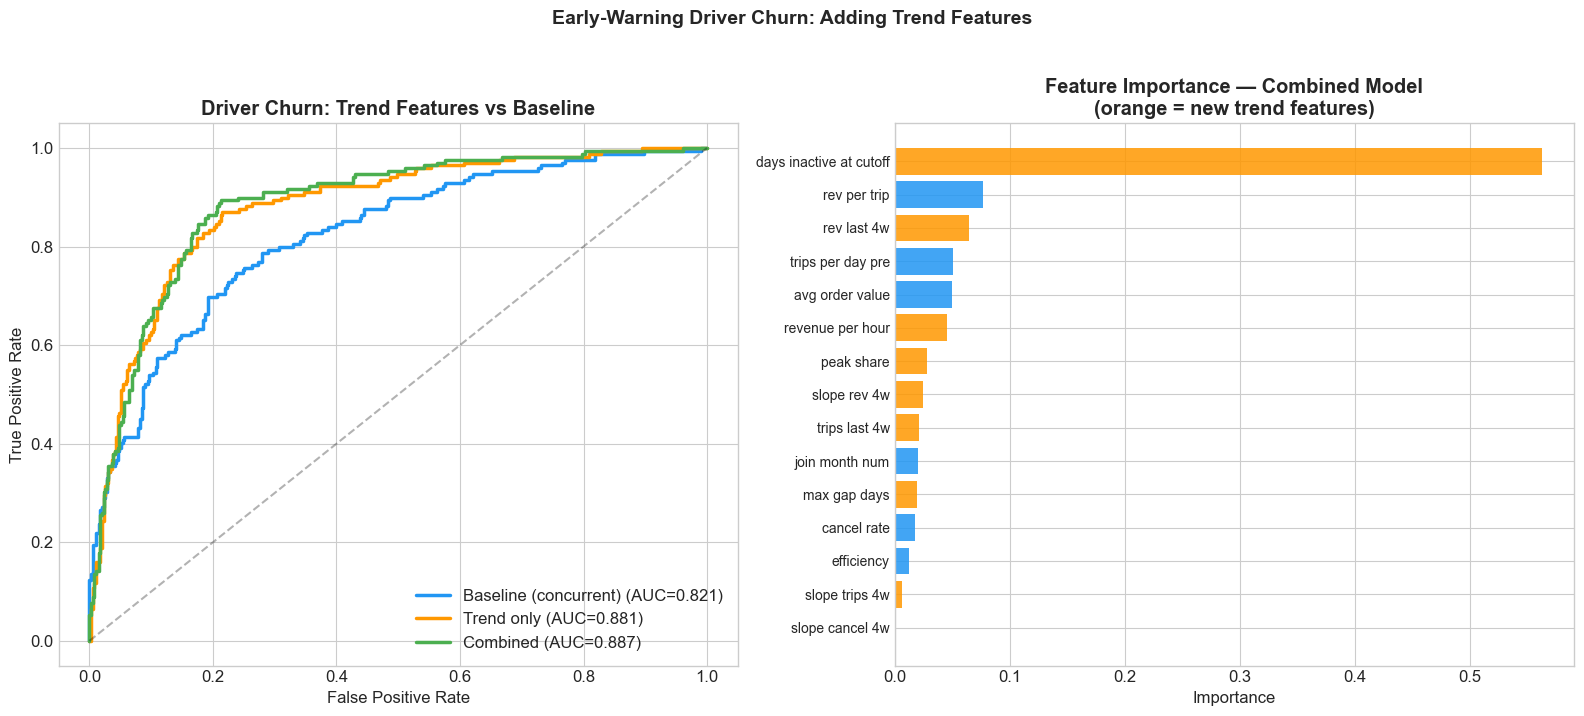


MODEL COMPARISON — EARLY-WARNING TREND FEATURES
Model                          CV AUC             Δ vs Baseline  
Baseline (concurrent)          0.821 ± 0.024     —
Trend only                     0.881 ± 0.033     +0.060
Combined                       0.887 ± 0.030     +0.065

Top trend features in combined model (median churned vs active):
  days_inactive_at_cutoff   importance=0.563  churned=   43.00  active=    1.00
  rev_last_4w               importance=0.065  churned=    0.00  active=14576.00
  revenue_per_hour          importance=0.046  churned=   36.16  active=   82.28
  peak_share                importance=0.028  churned=    0.12  active=    0.19
  slope_rev_4w              importance=0.024  churned=    0.00  active= 1178.00
  trips_last_4w             importance=0.021  churned=    0.00  active=   17.00


MODEL COMPARISON - EARLY-WARNING TREND FEATURES
Baseline concurrent model: CV AUC = 0.821 +/- 0.024.
Trend-only model: CV AUC = 0.881 +/- 0.033.
Combined model: CV AUC = 0.887 +/- 0.030.
The strongest signal is inactivity before the churn window; recent value and productivity features add useful but secondary signal.
Exact revenue-feature medians are omitted from the public output.


In [ ]:
import gc

orders_all = df_new.copy()
orders_all['driver_name'] = orders_all['Исполнитель'].astype(str).str.strip()
orders_all = orders_all[orders_all['driver_name'].notna() & (orders_all['driver_name'] != 'nan')]
orders_all['is_completed'] = orders_all['Текущий статус'].astype(str).str.contains('Выполнен', na=False)
orders_all['is_cancelled'] = orders_all['Текущий статус'].astype(str).str.contains('Отмен', na=False)
orders_all['revenue'] = pd.to_numeric(orders_all['Стоимость'], errors='coerce').fillna(0)
orders_all['hour'] = orders_all['date'].dt.hour
orders_all = orders_all.dropna(subset=['date'])

observation_end = orders_all['date'].max()
cutoff = observation_end - pd.Timedelta(days=30)
print(f'Observation end: {observation_end.date()}')
print(f'Cutoff (features must be ≤): {cutoff.date()}')

pre = orders_all[orders_all['date'] <= cutoff].copy()
post_completed = orders_all[(orders_all['date'] > cutoff) & orders_all['is_completed']]
drivers_active_post = set(post_completed['driver_name'].unique())

completed_pre = pre[pre['is_completed']]

drv_timeline = completed_pre.groupby('driver_name').agg(
    first_trip=('date', 'min'),
    last_trip_pre=('date', 'max'),
    pre_trips=('date', 'size')
).reset_index()

drv_timeline['churned'] = (~drv_timeline['driver_name'].isin(drivers_active_post)).astype(int)
drv_timeline['days_inactive_at_cutoff'] = (cutoff - drv_timeline['last_trip_pre']).dt.days.clip(lower=0)

print(f'Drivers with pre-cutoff history: {len(drv_timeline)}')
print(f'Churn rate (no trip in last 30 days): {drv_timeline["churned"].mean()*100:.1f}%')

win_A_start = cutoff - pd.Timedelta(days=28)
win_A_end   = cutoff - pd.Timedelta(days=14)
win_B_end   = cutoff

def sum_in_window(df_orders, start, end, col=None):
    mask = (df_orders['date'] > start) & (df_orders['date'] <= end)
    if col is None:
        return df_orders[mask].groupby('driver_name').size()
    return df_orders[mask].groupby('driver_name')[col].sum()

trips_A = sum_in_window(completed_pre, win_A_start, win_A_end).rename('trips_A')
trips_B = sum_in_window(completed_pre, win_A_end,   win_B_end).rename('trips_B')
rev_A   = sum_in_window(completed_pre, win_A_start, win_A_end, 'revenue').rename('rev_A')
rev_B   = sum_in_window(completed_pre, win_A_end,   win_B_end, 'revenue').rename('rev_B')

def cancel_rate_window(all_orders, start, end):
    m = (all_orders['date'] > start) & (all_orders['date'] <= end)
    w = all_orders[m].groupby('driver_name').agg(c=('is_cancelled','sum'), t=('is_cancelled','size'))
    return (w['c'] / w['t']).fillna(0)

cr_A = cancel_rate_window(pre, win_A_start, win_A_end).rename('cr_A')
cr_B = cancel_rate_window(pre, win_A_end,   win_B_end).rename('cr_B')

def max_gap(dates):
    if len(dates) < 2:
        return 0
    s = np.sort(dates.values)
    return int(pd.Series(np.diff(s)).dt.days.max())

max_gaps = completed_pre.groupby('driver_name')['date'].apply(max_gap).rename('max_gap_days')

completed_pre_peak = completed_pre.assign(is_peak=lambda d: d['hour'].isin([7,8,17,18]))
peak_share = completed_pre_peak.groupby('driver_name')['is_peak'].mean().rename('peak_share')

feat = drv_timeline.set_index('driver_name')
feat = feat.join([trips_A, trips_B, rev_A, rev_B, cr_A, cr_B, max_gaps, peak_share])
feat = feat.fillna({'trips_A':0, 'trips_B':0, 'rev_A':0, 'rev_B':0,
                    'cr_A':0, 'cr_B':0, 'max_gap_days':0, 'peak_share':0})

feat['slope_trips_4w']  = feat['trips_B'] - feat['trips_A']
feat['slope_rev_4w']    = feat['rev_B']   - feat['rev_A']
feat['slope_cancel_4w'] = feat['cr_B']    - feat['cr_A']
feat['trips_last_4w']   = feat['trips_A'] + feat['trips_B']
feat['rev_last_4w']     = feat['rev_A']   + feat['rev_B']

drv_cum = df_drv.set_index('name')[['cancel_rate','efficiency','rev_per_trip',
                                     'hours_online','revenue','total']]
feat = feat.join(drv_cum)
feat['revenue_per_hour'] = feat['revenue'] / feat['hours_online'].replace(0, np.nan)
feat['avg_order_value'] = feat['revenue'] / feat['total'].replace(0, np.nan)
feat['trips_per_day_pre'] = feat['pre_trips'] / (cutoff - feat['first_trip']).dt.days.clip(lower=1)
feat['join_month_num'] = (feat['first_trip'] - feat['first_trip'].min()).dt.days / 30

feat = feat.dropna(subset=['hours_online'])
print(f'Feature matrix after filtering: {len(feat)} drivers, {feat["churned"].sum()} churned '
      f'({feat["churned"].mean()*100:.1f}%)')

baseline_feats = ['cancel_rate', 'efficiency', 'rev_per_trip', 'avg_order_value',
                  'trips_per_day_pre', 'join_month_num']
trend_feats = ['slope_trips_4w', 'slope_rev_4w', 'slope_cancel_4w',
               'trips_last_4w', 'rev_last_4w', 'max_gap_days',
               'days_inactive_at_cutoff', 'peak_share', 'revenue_per_hour']
combined_feats = baseline_feats + trend_feats

def fit_cv(cols):
    X_ = feat[cols].fillna(0).replace([np.inf, -np.inf], 0)
    y_ = feat['churned']
    gb_ = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                     min_samples_leaf=10, random_state=42)
    cv_ = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores_ = cross_val_score(gb_, X_, y_, cv=cv_, scoring='roc_auc', n_jobs=1)
    proba_ = cross_val_predict(gb_, X_, y_, cv=cv_, method='predict_proba', n_jobs=1)[:, 1]
    gb_.fit(X_, y_)
    return scores_, proba_, gb_, X_, y_

print('\n── Training baseline (concurrent features only) ──')
s_b, p_b, gb_b, Xb, yb = fit_cv(baseline_feats)
print(f'Baseline CV AUC: {s_b.mean():.3f} ± {s_b.std():.3f}')

print('\n── Training trend-only ──')
s_t, p_t, gb_t, Xt, yt = fit_cv(trend_feats)
print(f'Trend CV AUC:    {s_t.mean():.3f} ± {s_t.std():.3f}')

print('\n── Training combined (baseline + trend) ──')
s_c, p_c, gb_c, Xc, yc = fit_cv(combined_feats)
print(f'Combined CV AUC: {s_c.mean():.3f} ± {s_c.std():.3f}')

fi_c = pd.Series(gb_c.feature_importances_, index=combined_feats).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for name, p_, score_, color_ in [
    ('Baseline (concurrent)', p_b, s_b.mean(), '#2196F3'),
    ('Trend only',            p_t, s_t.mean(), '#FF9800'),
    ('Combined',              p_c, s_c.mean(), '#4CAF50'),
]:
    fpr_, tpr_, _ = roc_curve(feat['churned'], p_)
    ax.plot(fpr_, tpr_, linewidth=2.5, label=f'{name} (AUC={score_:.3f})', color=color_)
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Driver Churn: Trend Features vs Baseline', fontweight='bold')
ax.legend()

ax = axes[1]
is_trend = [f_ in trend_feats for f_ in fi_c.index]
colors_fi = ['#FF9800' if t else '#2196F3' for t in is_trend]
ax.barh(range(len(fi_c)), fi_c.values, color=colors_fi, alpha=0.85)
ax.set_yticks(range(len(fi_c)))
ax.set_yticklabels([f_.replace('_',' ') for f_ in fi_c.index], fontsize=10)
ax.set_title('Feature Importance — Combined Model\n(orange = new trend features)', fontweight='bold')
ax.set_xlabel('Importance')

plt.suptitle('Early-Warning Driver Churn: Adding Trend Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_churn_trend_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*64)
print('MODEL COMPARISON — EARLY-WARNING TREND FEATURES')
print('='*64)
print(f'{"Model":<30} {"CV AUC":<18} {"Δ vs Baseline":<15}')
print(f'{"Baseline (concurrent)":<30} {s_b.mean():.3f} ± {s_b.std():.3f}     —')
print(f'{"Trend only":<30} {s_t.mean():.3f} ± {s_t.std():.3f}     {s_t.mean()-s_b.mean():+.3f}')
print(f'{"Combined":<30} {s_c.mean():.3f} ± {s_c.std():.3f}     {s_c.mean()-s_b.mean():+.3f}')

print(f'\nTop trend features in combined model (median churned vs active):')
trend_ranked = fi_c[fi_c.index.isin(trend_feats)].sort_values(ascending=False)
for name, imp in trend_ranked.head(6).items():
    ch_m = feat.loc[feat['churned']==1, name].median()
    ac_m = feat.loc[feat['churned']==0, name].median()
    print(f'  {name:<25} importance={imp:.3f}  churned={ch_m:>8.2f}  active={ac_m:>8.2f}')

feat_trend = feat.copy()
combined_churn_proba = p_c
gc.collect()


## 5. Driver Risk Matrix

The local analysis combines value and churn probability to prioritize outreach. In the public version, exact monetary values are cleared, but the structure of the risk-matrix logic remains visible.


In [ ]:
merged_clean['churn_prob'] = y_cv_proba

revenue_threshold = merged_clean['revenue'].median()
churn_threshold = 0.5

def classify_risk(row):
    hv = row['revenue'] >= revenue_threshold
    hr = row['churn_prob'] >= churn_threshold
    if hv and not hr: return 'Retain & Reward'
    elif hv and hr: return 'URGENT: Prevent Loss'
    elif not hv and not hr: return 'Develop'
    else: return 'Low Priority'

merged_clean['risk_segment'] = merged_clean.apply(classify_risk, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
colors_map = {
    'Retain & Reward': '#4CAF50',
    'URGENT: Prevent Loss': '#E53935',
    'Develop': '#2196F3',
    'Low Priority': '#9E9E9E'
}
for seg, color in colors_map.items():
    mask = merged_clean['risk_segment'] == seg
    ax.scatter(merged_clean.loc[mask, 'churn_prob'],
              merged_clean.loc[mask, 'revenue'],
              alpha=0.5, s=30, color=color, label=f'{seg} ({mask.sum()})')

ax.axvline(churn_threshold, color='gray', linestyle='--', alpha=0.5)
ax.axhline(revenue_threshold, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Churn Probability', fontsize=12)
ax.set_ylabel('Total Revenue (MUR)', fontsize=12)
ax.set_title('Driver Risk Matrix', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
seg_counts = merged_clean['risk_segment'].value_counts()
order = ['Retain & Reward', 'URGENT: Prevent Loss', 'Develop', 'Low Priority']
seg_counts = seg_counts.reindex(order).fillna(0)
colors_bar = [colors_map[s] for s in order]
ax.bar(range(len(order)), seg_counts.values, color=colors_bar, alpha=0.85)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([s.replace(' ', '\n') for s in order], fontsize=10)
ax.set_ylabel('Number of Drivers')
ax.set_title('Segment Distribution', fontweight='bold')
for i, v in enumerate(seg_counts.values):
    ax.text(i, v + 2, str(int(v)), ha='center', fontweight='bold')

plt.suptitle('Driver Value × Risk Segmentation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'RISK MATRIX RESULTS')
print(f'{"="*60}')
for seg in order:
    mask = merged_clean['risk_segment'] == seg
    n = mask.sum()
    rev = merged_clean.loc[mask, 'revenue'].sum()
    avg_churn = merged_clean.loc[mask, 'churn_prob'].mean()
    print(f'  {seg}: {n} drivers, revenue {rev:,.0f} MUR, avg churn prob {avg_churn:.2f}')


DRIVER RISK MATRIX SUMMARY
Retain and reward: 278 drivers, average churn probability 0.11.
Urgent outreach: 21 drivers, average churn probability 0.70.
Develop: 195 drivers, average churn probability 0.14.
Low priority: 103 drivers, average churn probability 0.80.
Exact revenue values and driver identifiers are omitted from the public output.


## 6. Customer-Value Cross-Check

Client-side value is used as supporting context for retention priorities. Exact customer value outputs are not retained in the repository version.


In [ ]:
completed_new = df_new[df_new['Текущий статус'].str.contains('Выполнен', na=False)]
avg_trip_value = completed_new['Стоимость'].median()

df_cli['has_ordered'] = df_cli['successful_orders'] > 0
df_cli['has_bonus'] = df_cli['bonus_mur'] > 0
df_cli['ltv_estimate'] = df_cli['successful_orders'] * avg_trip_value

df_cli['phone_str'] = df_cli['phone'].astype(str)
def classify_user_type(phone):
    if phone.startswith('2307'): return 'Tourist SIM'
    elif phone.startswith('230'): return 'Local'
    else: return 'International'

df_cli['user_type'] = df_cli['phone_str'].apply(classify_user_type)
df_cli['is_local'] = df_cli['user_type'] == 'Local'
df_cli['is_tourist_sim'] = df_cli['user_type'] == 'Tourist SIM'
df_cli['is_international'] = df_cli['user_type'] == 'International'

ordered = df_cli[df_cli['has_ordered']].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(ordered['ltv_estimate'].clip(upper=50000), bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(ordered['ltv_estimate'].median(), color='red', linestyle='--', linewidth=2,
           label=f'Median: {ordered["ltv_estimate"].median():,.0f} MUR')
ax.set_title('Customer LTV Distribution', fontweight='bold')
ax.set_xlabel('Estimated LTV (MUR)')
ax.set_ylabel('Clients')
ax.legend()

ax = axes[0, 1]
sorted_ltv = ordered['ltv_estimate'].sort_values(ascending=False).reset_index(drop=True)
cum_ltv = sorted_ltv.cumsum() / sorted_ltv.sum() * 100
client_pct = np.arange(1, len(sorted_ltv)+1) / len(sorted_ltv) * 100
ax.plot(client_pct, cum_ltv, color='#FF5722', linewidth=2.5)
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
idx80c = np.argmax(cum_ltv >= 80)
pct80c = client_pct[idx80c]
ax.axvline(pct80c, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'{pct80c:.0f}% of clients\ngenerate 80% of value',
            xy=(pct80c, 80), xytext=(pct80c+15, 60), fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Customer LTV Pareto', fontweight='bold')
ax.set_xlabel('% of Clients')
ax.set_ylabel('% of Total LTV')

ax = axes[1, 0]
local_ltv = ordered[ordered['is_local']]['ltv_estimate']
tourist_sim_ltv = ordered[ordered['is_tourist_sim']]['ltv_estimate']
intl_ltv = ordered[ordered['is_international']]['ltv_estimate']
data_box = [local_ltv.clip(upper=30000), tourist_sim_ltv.clip(upper=30000), intl_ltv.clip(upper=30000)]
bp = ax.boxplot(data_box, labels=['Local', 'Tourist SIM', 'International'], patch_artist=True,
                boxprops=dict(alpha=0.7), medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#E91E63')
bp['boxes'][2].set_facecolor('#2196F3')
ax.set_title('LTV by User Segment', fontweight='bold')
ax.set_ylabel('Estimated LTV (MUR)')
ax.text(1, local_ltv.median()+500, f'Median: {local_ltv.median():,.0f}', ha='center', fontweight='bold')
ax.text(2, tourist_sim_ltv.median()+500, f'Median: {tourist_sim_ltv.median():,.0f}', ha='center', fontweight='bold')
ax.text(3, intl_ltv.median()+500, f'Median: {intl_ltv.median():,.0f}', ha='center', fontweight='bold')

ax = axes[1, 1]
bonus_ltv = ordered[ordered['has_bonus']]['ltv_estimate']
no_bonus_ltv = ordered[~ordered['has_bonus']]['ltv_estimate']
means = [no_bonus_ltv.mean(), bonus_ltv.mean()]
medians = [no_bonus_ltv.median(), bonus_ltv.median()]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, means, w, label='Mean LTV', color='#2196F3', alpha=0.7)
ax.bar(x + w/2, medians, w, label='Median LTV', color='#FF5722', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(['No Bonus', 'Has Bonus'])
ax.set_title('Bonus Program Impact on LTV', fontweight='bold')
ax.set_ylabel('Estimated LTV (MUR)')
ax.legend()
for i, (m, md_val) in enumerate(zip(means, medians)):
    ax.text(i - w/2, m + 200, f'{m:,.0f}', ha='center', fontweight='bold', fontsize=9)
    ax.text(i + w/2, md_val + 200, f'{md_val:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Customer Lifetime Value Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_customer_ltv.png', dpi=150, bbox_inches='tight')
plt.show()

non_ordered = df_cli[~df_cli['has_ordered']]
potential_ltv = len(non_ordered) * ordered['ltv_estimate'].median()

print(f"\n{'='*60}")
print(f"CUSTOMER LTV SUMMARY")
print(f"{'='*60}")
print(f"Active clients (≥1 order): {len(ordered):,}")
print(f"Avg trip value: {avg_trip_value:,.0f} MUR")
print(f"Median LTV: {ordered['ltv_estimate'].median():,.0f} MUR ({ordered['successful_orders'].median():.0f} trips)")
print(f"Mean LTV: {ordered['ltv_estimate'].mean():,.0f} MUR ({ordered['successful_orders'].mean():.1f} trips)")
print(f"Pareto: {pct80c:.0f}% of clients generate 80% of value")
print(f"\nLocal vs International:")
print(f"  Local median LTV: {local_ltv.median():,.0f} MUR ({ordered[ordered['is_local']]['successful_orders'].median():.0f} trips)")
print(f"  Tourist SIM median LTV: {tourist_sim_ltv.median():,.0f} MUR ({ordered[ordered['is_tourist_sim']]['successful_orders'].median():.0f} trips)")
print(f"  Intl median LTV: {intl_ltv.median():,.0f} MUR ({ordered[ordered['is_international']]['successful_orders'].median():.0f} trips)")
print(f"  Local clients have {local_ltv.median()/intl_ltv.median():.1f}x higher median LTV")
print(f"\nBonus program effect:")
print(f"  With bonus: mean {bonus_ltv.mean():,.0f} MUR")
print(f"  Without bonus: mean {no_bonus_ltv.mean():,.0f} MUR")
print(f"  Bonus lift: {bonus_ltv.mean()/no_bonus_ltv.mean():.1f}x")
print(f"\nConversion opportunity:")
print(f"  {len(non_ordered):,} registered users never ordered")
print(f"  Potential value at median LTV: {potential_ltv:,.0f} MUR")


CUSTOMER VALUE CROSS-CHECK SUMMARY
Active clients with at least one order: 17,382.
Relative concentration: the top 42% of clients account for 80% of value.
Bonus-associated users show about 2.3x higher mean relative value than users without bonus activity.
Registered users who never ordered: 17,586. Exact monetary LTV values are omitted from the public output.


## 7. Driver-Side Summary

This notebook provides the driver-side evidence for Section 3.4.3 of the thesis. It combines value concentration, survival analysis, churn prediction and an early-warning logic for driver retention.

Main conclusions:

- Driver activity is unevenly distributed, so retention should prioritize the drivers who contribute most to operational capacity.
- Survival analysis shows a clear difference between high-volume and low-volume drivers, supporting the engagement-based interpretation of driver retention.
- The corrected churn model uses a timeline-based label rather than a behavioral proxy.
- Trend features improve early-warning performance, especially recent inactivity and short-term activity changes.
- The final driver recommendation is therefore not simply to reduce commission, but to monitor engagement and intervene before high-value drivers disappear.

Limitations:

- Exact monetary totals are omitted from the repository version.
- Driver risk categories should be treated as prioritization tools, not automatic decisions.
- The early-warning setup should be recalibrated as more post-migration data becomes available.

Thesis use:

- Chapter 3 uses this notebook for driver lifetime value, survival, churn prediction and the risk matrix.
- Chapter 4 uses it to justify driver engagement, early-warning monitoring and targeted retention recommendations.
